In [1]:
# Imports to use for this module
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df1 = pd.read_csv('../../assignments/programming/sample_data/synthetic_data.csv')

df1.head()

,category,value_1,value_2,size
0,A,13.0,55.4,443
1,A,11.7,59.2,212
2,A,13.3,55.5,370
3,A,15.0,59.6,306
4,A,11.5,56.5,422


In [11]:
category_df = df1.groupby("category")["value_2"].mean().reset_index()

category_df.head()

,category,value_2
0,A,56.1500
1,B,38.6500
2,C,22.0625


In [36]:
help(sns.boxplot)

Help on function boxplot in module seaborn.categorical:

boxplot(data=None, *, x=None, y=None, hue=None, order=None, hue_order=None, orient=None, color=None, palette=None, saturation=0.75, fill=True, dodge='auto', width=0.8, gap=0, whis=1.5, linecolor='auto', linewidth=None, fliersize=None, hue_norm=None, native_scale=False, log_scale=None, formatter=None, legend='auto', ax=None, **kwargs)
    Draw a box plot to show distributions with respect to categories.
    
    A box plot (or box-and-whisker plot) shows the distribution of quantitative
    data in a way that facilitates comparisons between variables or across
    levels of a categorical variable. The box shows the quartiles of the
    dataset while the whiskers extend to show the rest of the distribution,
    except for points that are determined to be "outliers" using a method
    that is a function of the inter-quartile range.
    
    See the :ref:`tutorial <categorical_tutorial>` for more information.
    
    .. note::
     

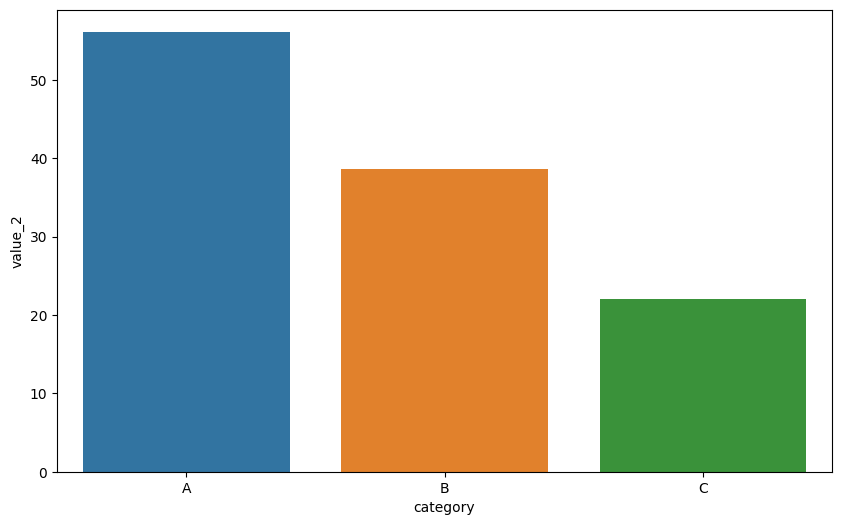

In [12]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=category_df,
    x= "category",
    y = "value_2",
    hue="category"
)

plt.xlabel = "Category"
plt.ylabel = "Value"

plt.show()

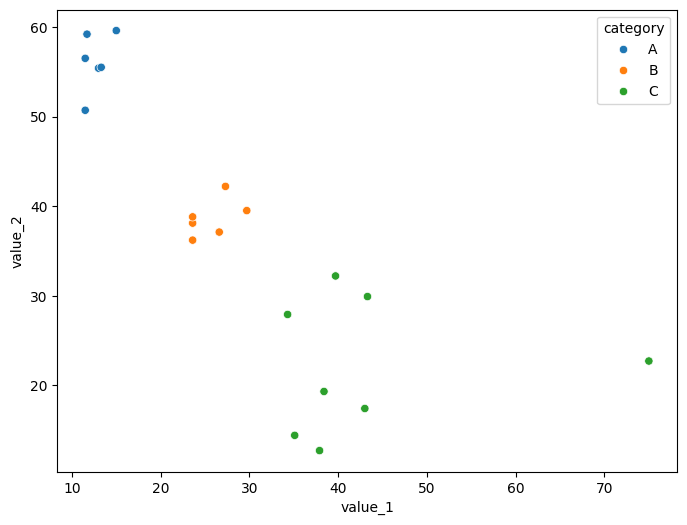

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df1,
    x = "value_1",
    y = "value_2",
    hue="category"
)

plt.show()

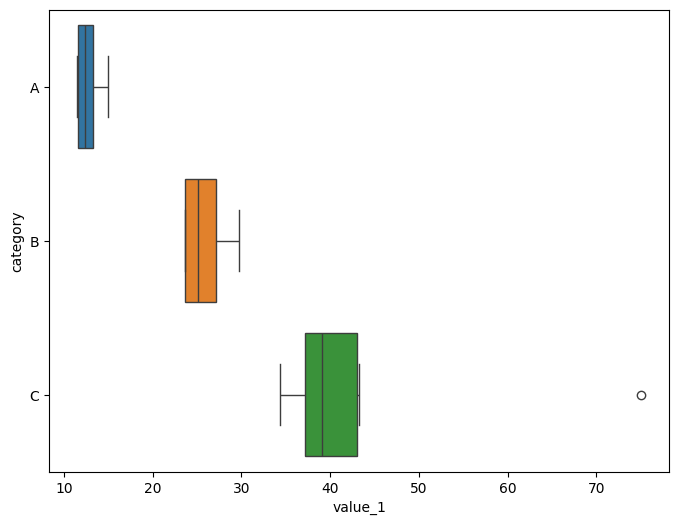

In [16]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df1,
    y = "category",
    x = "value_1",
    hue = "category"
)

plt.show()

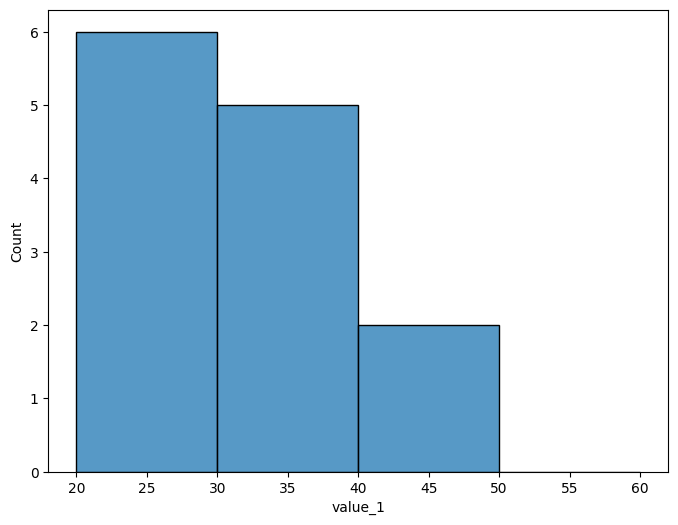

In [18]:
plt.figure(figsize=(8,6))

sns.histplot(
    data=df1,
    x="value_1",
    bins=[20, 30, 40, 50, 60]
)

plt.show()

In [27]:
df1[ (df1["value_2"]>=20) & (df1["value_2"]<30)].shape[0]

3

In [28]:
df2 = sns.load_dataset('tips')

In [29]:
df2.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


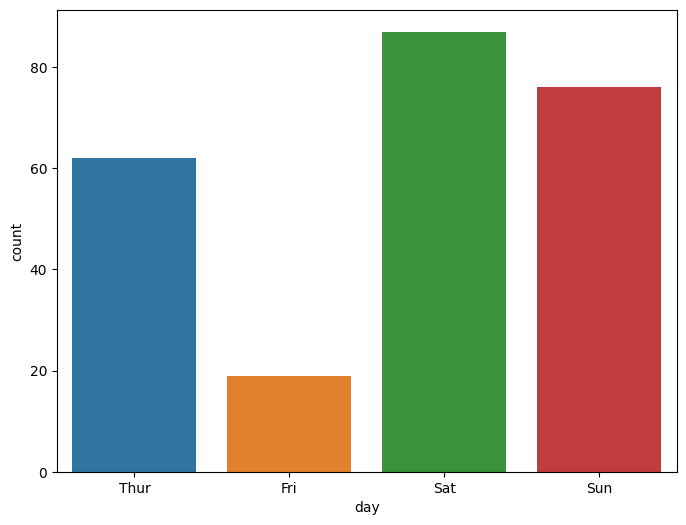

In [33]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df2,
    x="day",
    hue="day"
)

plt.show()

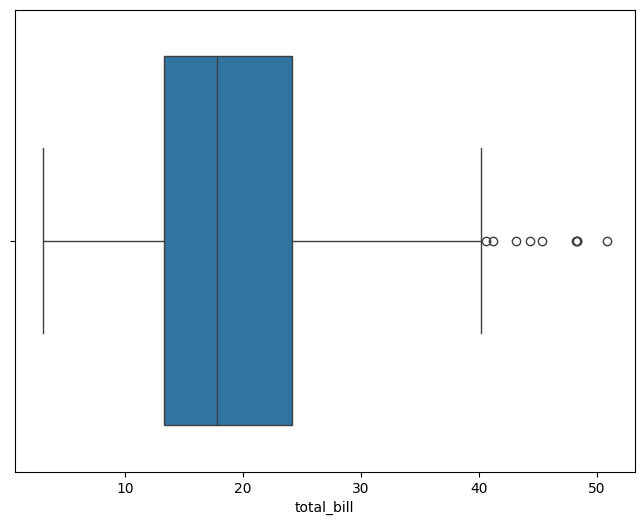

In [35]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df2,
    x = "total_bill",
)

plt.show()

In [41]:
df2["total_bill"].median()

np.float64(17.795)

In [44]:
gender_tip = df2.groupby("sex")["tip"].mean().reset_index()
gender_tip.head()

C:\Users\ankit\AppData\Local\Temp\ipykernel_11976\3318255132.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_tip = df2.groupby("sex")["tip"].mean().reset_index()


,sex,tip
0,Male,3.089618
1,Female,2.833448


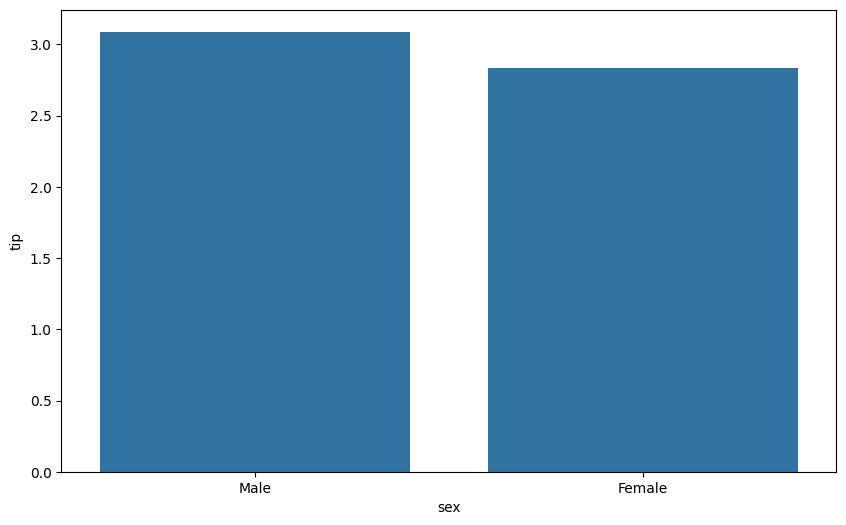

In [46]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=gender_tip,
    x = "sex",
    y = "tip"
)

plt.show()

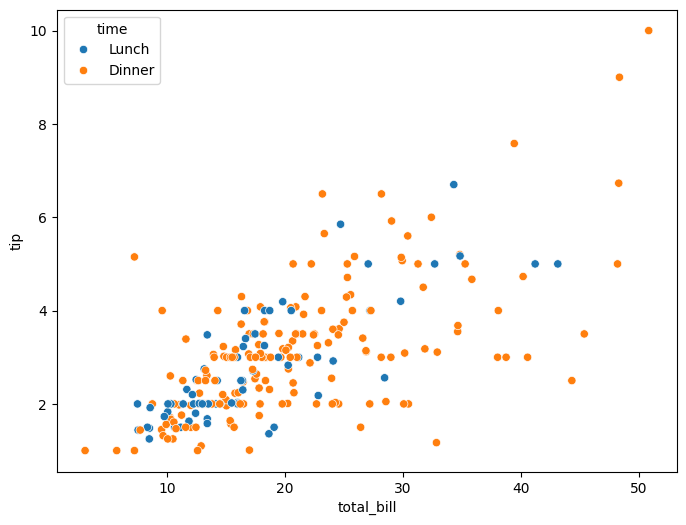

In [47]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df2,
    x = "total_bill",
    y = "tip",
    hue = "time"
)

plt.show()

### Create pivot table

In [56]:
def get_pivot_val(df, date, category):
    '''
    Create a pivot table where rows are 'Date', columns are 'Category',
    and values are the mean of 'Values'. Fill missing entries with 0.
    Return the specific value at the intersection of the given date and category.
    
    Parameters:
    - df: DataFrame with 'Date', 'Category', 'Values'
    - date: (str) The index label to lookup
    - category: (str) The column label to lookup
    
    Return Value: Float
    '''
    pvt = pd.pivot_table(df, values="Values", columns="Category", index="Date", fill_value=0)
    if category not in pvt.columns:
        return 0.0
    if date not in pvt.index:
        return 0.0
    return pvt[category][date]


In [60]:
num_rows = 10
df = pd.DataFrame({
    'Date': np.random.choice(pd.date_range(start="2024-01-01", periods=5, freq="1D"), num_rows),
    'Category': np.random.choice(['A', 'B', 'C', 'D'], num_rows),
    'Values': 10 + np.random.rand(num_rows) * 10
})

print(df.head())

print(get_pivot_val(df, '2024-01-03', 'C'))

        Date Category     Values
0 2024-01-03        C  18.213186
1 2024-01-01        B  13.472587
2 2024-01-03        A  11.721952
3 2024-01-01        D  14.858535
4 2024-01-02        C  13.405994
18.21318628260236


In [108]:
def get_dept_avg_salary(df, target_dept):
    '''
    Group the data by 'Department'. Calculate and return the mean
    salary for the specific target_dept.
    
    Parameters:
    - df: DataFrame with 'Department', 'Salary'
    - target_dept: (str) The department to query
    
    Return Value: A floating-point number rounded to two decimal places.
    '''
    if target_dept not in list(df['Department']):
        return 0.0
    df = df.groupby('Department')["Salary"].mean().reset_index()
    mean = df.loc[df["Department"]==target_dept, "Salary"].values[0]
    # print(mean.shape, mean)
    return round(mean,2)


In [109]:
num_rows = 10
df = pd.DataFrame({
    'Department': np.random.choice(['HR', 'IT', 'Sales'], num_rows),
    'Salary': 10000 + np.random.rand(num_rows) * 10000
})
# print(df)
print(get_dept_avg_salary(df, 'Sales'))

16109.59


In [110]:
def count_unique_months(df):
    '''
    Convert the 'TransactionDate' column to datetime objects.
    Extract the month names (e.g., 'January').
    Return the number of unique month names present in the dataset.
    
    Parameters:
    - df: DataFrame with 'TransactionDate' (string)
    
    Return Value: Integer
    '''
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
    return df['TransactionDate'].dt.month_name().nunique()

In [111]:
data = {
    'TransactionDate': ['2025-01-15', '2025-02-20', '2025-02-25', '2025-03-10', '2025-01-30']
}
df = pd.DataFrame(data)
print(count_unique_months(df))

3


In [128]:
def get_clean_quantity_total(df):
    '''
    1. Fill missing 'Quantity' values with 0.
    2. Drop any rows where 'Price' is missing (NaN).
    3. Return the sum of the 'Quantity' column from the remaining rows.
    
    Parameters:
    - df: DataFrame with 'Product', 'Price', 'Quantity'
    
    Return Value: Float
    '''
    df.loc[df['Quantity'].isna(), 'Quantity'] = 0
    df = df[~df['Price'].isna()]
    print(df)
    return df['Quantity'].sum().item()

In [129]:
num_rows = 10
df = pd.DataFrame({
    'Product': np.random.choice(['A','B', 'C', 'D'], num_rows),
    'Price' : np.random.choice([100, 130, np.nan], num_rows),
    'Quantity': np.random.choice([10, 20, 30, np.nan], num_rows)
})
print(df)
print(get_clean_quantity_total(df))

  Product  Price  Quantity
0       C  130.0      20.0
1       D    NaN      10.0
2       C    NaN       NaN
3       D  130.0      20.0
4       C  100.0      10.0
5       B    NaN      10.0
6       C    NaN       NaN
7       A    NaN       NaN
8       A  100.0      10.0
9       D  100.0      30.0
  Product  Price  Quantity
0       C  130.0      20.0
3       D  130.0      20.0
4       C  100.0      10.0
8       A  100.0      10.0
9       D  100.0      30.0
90.0


In [132]:
'''
Write a Python function sort_words(words) that accepts a list of strings. It should return a new list sorted by the following criteria:

Primary: Length of the word (shortest to longest).
Secondary: Alphabetical order (A-Z) for words of the same length.
Constraint: You must use sorted() with a lambda function for the key.

Additional Notes:

Assume words is non-empty (contains at least one word)
Example:

words = ["apple", "bat", "dog", "cat", "elephant"] print(sort_words(words))
# Expected Output: ["bat", "cat", "dog", "apple", "elephant"]
# Explanation: Sorted by length (3, 3, 3, 5, 8), then alphabetically within same length.
'''
def sort_words(words):
    return sorted(sorted(words), key=lambda x: len(x))

In [133]:
print(sort_words(["apple", "bat", "dog", "cat", "elephant"]))

['bat', 'cat', 'dog', 'apple', 'elephant']


In [135]:
'''
Write a Python function intersect_sorted_lists(A, B) that takes two sorted lists and returns a new list containing their intersection.

If an element appears multiple times in both lists, it should appear in the result as many times as it appears in the list with the lower count of that element.
Constraint: Use the "Two Pointer" merge logic. Do NOT use sets.
Example:

A = [1, 2, 2, 4, 6]
B = [2, 2, 4, 5]
print(intersect_sorted_lists(A, B))
# Expected Output: [2, 2, 4]
# Explanation: 
#   - '1' only in A
#   - '2' appears 2 times in A, 2 times in B → include 2 times
#   - '4' appears 1 time in A, 1 time in B → include 1 time
#   - '5' only in B
#   - '6' only in A

**Edge Case:**
- Handle empty lists gracefully. If either list A or B is empty, return 
an empty list.

Example:
```python
A = []
B = [1, 2, 3]
# Output: []
'''

def intersect_sorted_lists(A, B):
    #Write solution code here
    if len(A)==0 or len(B)==0:
        return []
    return [x for x in A if x in B]


In [136]:
A = [1, 2, 2, 4, 6]     
B = [2, 2, 4, 5]    
print(intersect_sorted_lists(A, B))  

[2, 2, 4]


In [137]:
def intersect_unique_sorted_list(A, B):
    if len(A)==0 or len(B)==0:
        return []

    return list(set(A) & set(B))    

In [140]:
def intersect_unique_sorted_list_2(A, B):
    if len(A)==0 or len(B)==0:
        return []

    return [x for x in set(A) if x in set(B)]  

In [147]:
def intersect_unique_sorted_list_3(A, B):
    if len(A)==0 or len(B)==0:
        return []

    return list(filter(lambda x: x in B , set(A))) 

In [148]:
A = [1, 2, 2, 4, 6]     
B = [2, 2, 4, 5]    
print(intersect_unique_sorted_list(A, B))
print(intersect_unique_sorted_list_2(A, B))
print(intersect_unique_sorted_list_3(A, B))

[2, 4]
[2, 4]
[2, 4]


In [175]:
'''
You are given a list of k sorted integer arrays. Write a function merge_k_lists(lists) that merges all arrays into one single sorted array.

Constraint: You must use the heapq module to solve this efficiently (O(N log k) where N is total elements).
Handle edge cases: Some arrays in lists may be empty
Expected behavior: Skip empty arrays and merge only non-empty ones

Example:

lists = [
  [1, 4, 5],
  [1, 3, 4],
  [2, 6]
]
print(merge_k_lists(lists))
# Expected Output: [1, 1, 2, 3, 4, 4, 5, 6]
'''

import heapq
def merge_k_lists(lists):
    result = []
    for l in lists:
        # heapq.heapify(l)
        result = list(heapq.merge(result, l))
    return result

In [ ]:
# This code does not work as expected. This is just for experimental purpose
import heapq
def merge_k_lists_2(lists):
    result = [x for sublist in lists for x in sublist]
    heapq.heapify(result)
    return result

In [180]:
lists = [
  [1, 4, 5],
  [1, 3, 4],
  [2, 6]
]
print(merge_k_lists(lists))
print(merge_k_lists_2(lists))

[1, 1, 2, 3, 4, 4, 5, 6]
[1, 4, 5, 1, 3, 4, 2, 6]


In [200]:
from collections import deque

def valid(u, v, r, c):
    return (u>=0 and u<r) and (v>=0 and v<c)

def numIslands(grid):
    #Write solution code here
    r = len(grid)
    if r<=0:
        return 0
    c = len(grid[0])

    Q = deque([])

    visited = [[0 for _ in range(len(grid[0]))] for _ in range(len(grid))]

    count = 0        
    for i in range(r):
        for j in range(c):
            if not visited[i][j] and grid[i][j] == "1":
                count += 1
                Q.append((i,j))
                visited[i][j] = True
                while len(Q)!=0:
                    (u, v) = Q.pop()
                    if valid(u+1,v, r, c) and grid[u+1][v] == "1" and not visited[u+1][v]:
                        Q.append((u+1, v))
                        visited[u+1][v] = True
                    if valid(u,v+1, r, c) and grid[u][v+1] == "1" and not visited[u][v+1]:
                        Q.append((u, v+1))
                        visited[u][v+1] = True

    # print(visited)
    return count

In [201]:
grid1 = [
  ["1","1","1","1","1"],
  ["1","1","0","1","0"],
  ["1","1","0","0","0"],
  ["0","0","0","0","0"]
]
print(numIslands(grid1))

1


In [202]:
grid2 = [
  ["1","1","0","0","0"],
  ["1","1","0","0","0"],
  ["0","0","1","0","0"],
  ["0","0","0","1","1"]
]
print(numIslands(grid2))

3


In [234]:
'''
df -> Region, Product, Sales, Month
'''
def group_sales_total(data, month_filter, group_var, group_value):
    df = pd.DataFrame(data)
    df = df[df["Month"] == month_filter]
    sales_df = df.groupby(group_var)['Sales'].sum().reset_index()
    if group_value not in list(sales_df[group_var]):
        return 0
    return sales_df[sales_df[group_var] == group_value]['Sales'].item()

In [235]:
sales_data = {
    "Region": ["North", "South", "East", "West", "North", "East", "South", "West"],
    "Product": ['A', 'A', 'B', 'B', 'C', 'C', 'A', 'B'],
    "Sales": [1200, 800, 600, 900, 1500, 700, 650, 1100],
    "Month": ['Jan', 'Jan', 'Feb', 'Feb', 'Jan', 'Feb', 'Feb', 'Jan']
}

print(group_sales_total(sales_data, "Jan", 'Region', 'West'))
print(group_sales_total(sales_data, "Feb", 'Product', 'C'))
print(group_sales_total(sales_data, "Jan", 'Region', 'Central'))

1100
700
0
